# Cliff Walking: Q-Learning

## Installation and Setup

In [1]:
# uncomment if needed
# %pip install "gym-classics2 @ git+https://github.com/mhahsler/gym-classics2.git"

In [2]:
import numpy as np
np.set_printoptions(precision=2)

SEED = 42
rng = np.random.default_rng(SEED)

In [3]:
import gymnasium as gym
import gym_classics2
gym_classics2.register('gymnasium')

from gym_classics2.animation import gridworld_animate                               
from gym_classics2.algorithms.policy import random_policy

## Cliff Walking

Example from Sutton/Barto Chapter 6.

![Clif Walking problem description](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-intro_Cliffwalking.png)

Cliff Walking is a standard undiscounted,
episodic task, with start
and goal states, and the usual actions
causing movement up, down,
right, and left. Reward is −1 on all
transitions except those into the region
marked “The Cliff.” Stepping
into this region incurs a reward of
−100 and sends the agent instantly
back to the start.

In [4]:
gym_env = gym.make('CliffWalk-v1', tabular = True)
env = gym_env.unwrapped
env.reset(seed=SEED)

(0, {})

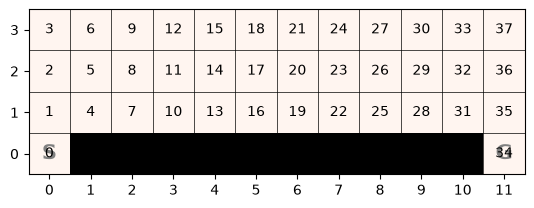

In [5]:
env.image()

## Optimal Policy

This environment has model access, so we can for comparison use value iteration to find the optimal policy.

Value Iteration: 0it [00:00, ?it/s]

Value Iteration: 14it [00:00, 661.79it/s]


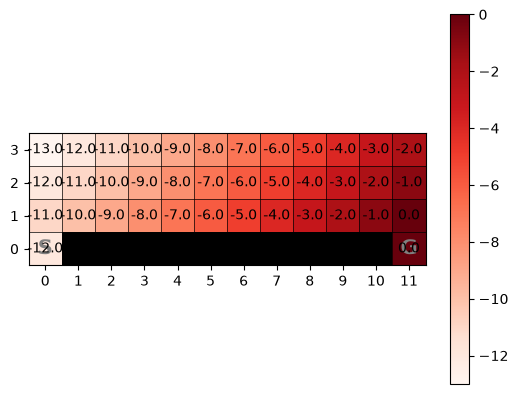

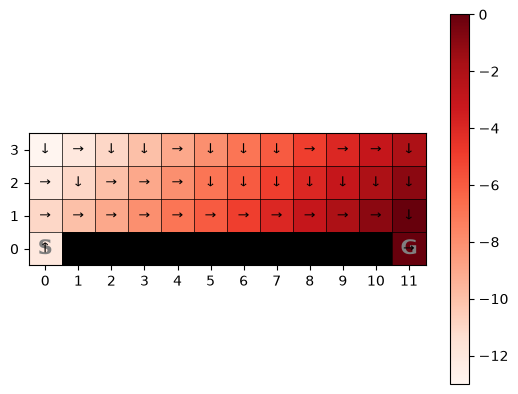

In [6]:
from gym_classics2.algorithms.dynamic_programming import value_iteration
from gym_classics2.algorithms.policy import greedy_policy

V_star = value_iteration(env, discount=1)
policy_star = greedy_policy(V_star, env, discount=1, rng=rng)

env.image(V_star, labels=True)
env.image(V_star, policy=policy_star)

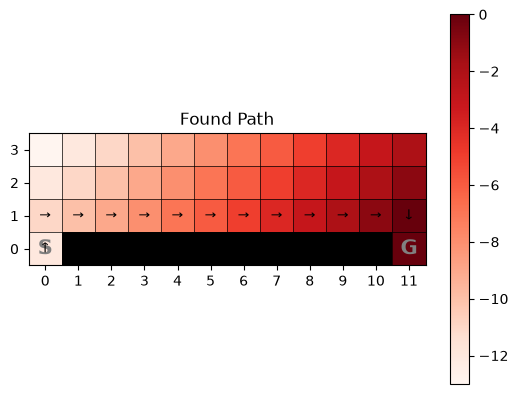

In [7]:
from gym_classics2.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=policy_star, max_len=100)
env.image(V=V_star, policy=policy_star, episode=path, title='Found Path')

The optimal policy leads along the cliff.

**Note:** Actions in the goal state are artifacts and do not matter!

## Off-Policy: Q-Learning

![Algorithm: Q-learning](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_Q-learning.png)

In [8]:
from tqdm import tqdm

# np.argmax does not break ties randomly
def random_argmax(x, rng):
    return rng.choice(np.where(x == np.max(x))[0])

def Q_learning(env, discount, alpha, epsilon, n=100, verbose=False, rng=None):
    rng = np.random.default_rng(rng)
    Q = np.zeros((len(env.states()), len(env.actions())))
    
    for i in tqdm(range(n), desc="Q-Learning", disable=verbose):
        s, r = env.reset()
          
        done = False
        while not done:
            # epsilon-greedy choice w.r.t. Q 
            if rng.random() > epsilon:
                a = random_argmax(Q[s,:], rng)
            else:
                a = rng.integers(env.action_space.n)
            
            sp, r, done, _, _ = env.step(a)
        
            Q[s,a] = Q[s,a] + alpha * (r + discount * np.max(Q[sp,:]) - Q[s,a])
            
            s = sp
          
    return Q

$\epsilon$ is for the behavior policy, but Q-learning learns a deterministic policy.

In [9]:
Q = Q_learning(env, discount=1, alpha=.1, epsilon=.1, n=1000, rng=rng)

Q-Learning: 100%|██████████| 1000/1000 [00:00<00:00, 2600.98it/s]


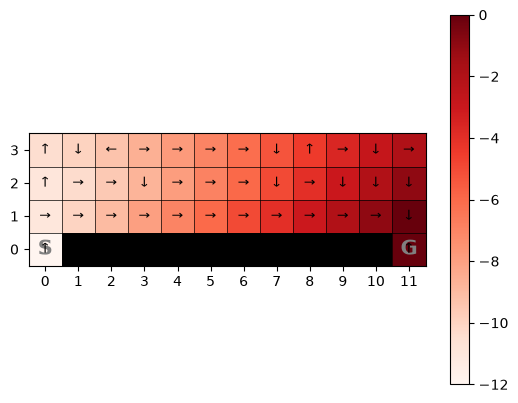

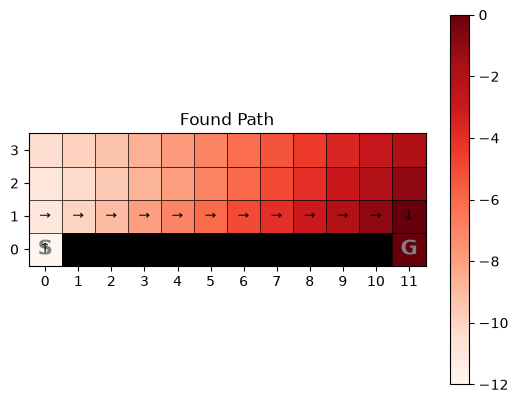

In [10]:
policy = np.argmax(Q, axis=1)
V = np.max(Q, axis = 1)

env.image(V, policy = policy)
path = sample_episode(env, policy=policy, max_len=100)
env.image(V=V, policy=policy, episode=path, title='Found Path')

Running Q-learning with a larger $\epsilon$

In [11]:
Q = Q_learning(env, discount=1, alpha=.1, epsilon=.5, n=1000, rng=rng)

Q-Learning:   0%|          | 0/1000 [00:00<?, ?it/s]

Q-Learning: 100%|██████████| 1000/1000 [00:01<00:00, 588.28it/s]


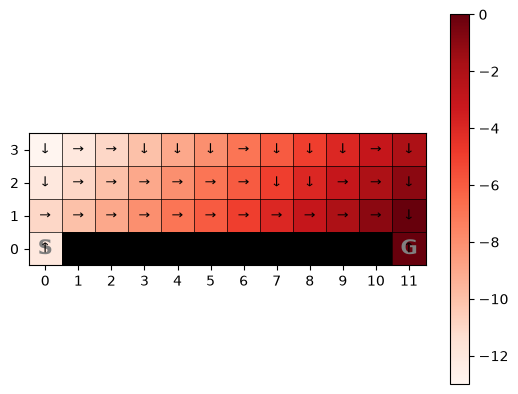

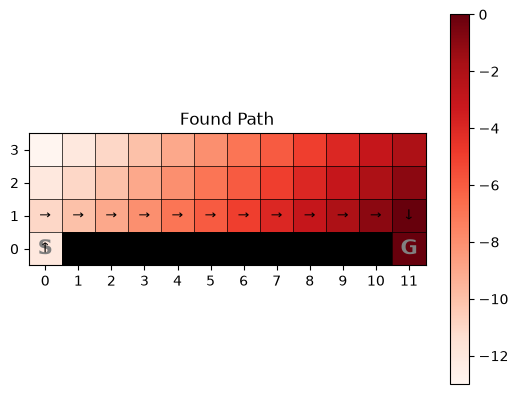

In [12]:
policy = np.argmax(Q, axis=1)
V = np.max(Q, axis = 1)

env.image(V, policy = policy)
path = sample_episode(env, policy=policy, max_len=100)
env.image(V=V, policy=policy, episode=path, title='Found Path')

**Note:** Q-Learning is off-policy and learns the optimal deterministic policy which is the shortest path along the cliff. This is not affected by
the $\epsilon$ used for the behavior policy as long as the policy is soft (exploring).

#### Performance of the Final Policy

We have extracted a deterministic greedy policy from the learned Q-function. Since the actions are also deterministic, we can sample a single episode
and calculate the return.

In [13]:
from gym_classics2.algorithms.monte_carlo_methods import sample_episode

episode = sample_episode(env, policy = policy)
display(episode)

discount = 1
rewards = np.array([sars[2] for sars in episode])
np.sum(rewards * np.power(discount, range(len(episode))))

[(0, np.int64(0), -1.0, 1),
 (1, np.int64(1), -1.0, 4),
 (4, np.int64(1), -1.0, 7),
 (7, np.int64(1), -1.0, 10),
 (10, np.int64(1), -1.0, 13),
 (13, np.int64(1), -1.0, 16),
 (16, np.int64(1), -1.0, 19),
 (19, np.int64(1), -1.0, 22),
 (22, np.int64(1), -1.0, 25),
 (25, np.int64(1), -1.0, 28),
 (28, np.int64(1), -1.0, 31),
 (31, np.int64(1), -1.0, 35),
 (35, np.int64(2), 0.0, 34)]

np.float64(-12.0)

This is better then Sarsa, because Q-learning learns the optimal deterministic policy.

#### Performance During Learning

We look at the return for each episode during the first 500 episodes of learning.

In [14]:
def Q_learning_returns(env, discount, alpha, epsilon, n=100, rng=None):
    rng = np.random.default_rng(rng)
    # keep track of the returns
    Returns = [0] * n 
    
    Q = np.zeros((len(env.states()), len(env.actions())))
    state_visits = np.zeros(len(env.states()), dtype=int)
    
    for i in tqdm(range(n), desc="Q-Learning Returns"):
        s, r = env.reset()
          
        state_visits[s] += 1
          
        t = 0
        done = False
        while not done:
            # epsilon-greedy choice w.r.t. Q 
            if rng.random() > epsilon:
                a = random_argmax(Q[s,:], rng)
            else:
                a = rng.integers(env.action_space.n)
            
            sp, r, done, _, _ = env.step(a)
            state_visits[sp] += 1
            
            Returns[i] += r * pow(discount, t)
            t += 1
        
            Q[s,a] = Q[s,a] + alpha * (r + discount * np.max(Q[sp,:]) - Q[s,a])
            
            s = sp
          
    return Q, Returns, state_visits

In [15]:
Q, returns, state_visits = Q_learning_returns(env, discount=1, alpha=.1, epsilon=.1, n=500, rng=rng)

Q-Learning Returns: 100%|██████████| 500/500 [00:00<00:00, 631.11it/s]


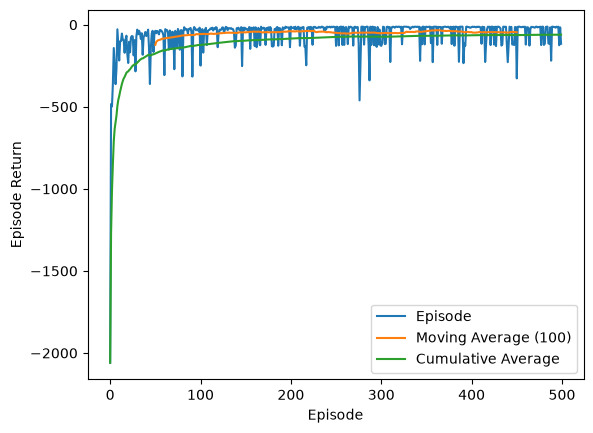

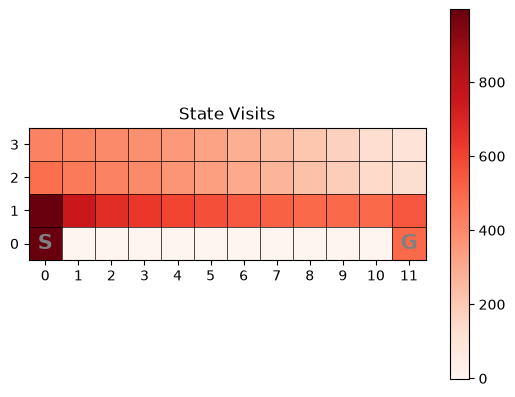

In [16]:
from gym_classics2.performance import plot_returns
plot_returns(returns)
env.image(V = state_visits, title="State Visits", cmap="Reds")

Overall, mostly the states on the shortest path are visited.

Note that bad episode returns persist. This is due to the continued exploration of the behavioral policy, even after learning has converged to the optimal policy. 


### Initial behavior

Q-Learning Returns:   0%|          | 0/10 [00:00<?, ?it/s]

Q-Learning Returns: 100%|██████████| 10/10 [00:00<00:00, 96.28it/s]


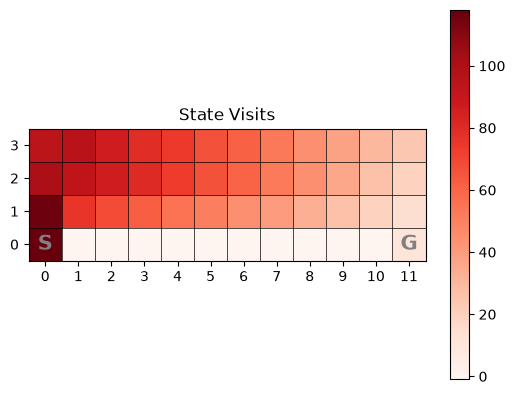

In [17]:
Q, returns, state_visits = Q_learning_returns(env, discount=1, alpha=.1, epsilon=.1, n=10, rng=rng)
env.image(V = state_visits, title="State Visits", cmap="Reds")

The agent starts with random exploration behavior, avoids the cliff edge and does not want to move away from the left side of the grid world!

Notes: 

* Q-learning runs into the cliff more often than Sarsa during learning because it chooses the path right next to the cliff while still exploring with an $\epsilon$-soft policy. The learned deterministic policy will become optimal leading to the optimal return. 
* Q-Learning does not need GLIE for learning because it is off-policy! However, if we want the agent to behave better and better as it learns, then reducing $\epsilon$ with a schedule will help.  
* Learning performance for all TD-methods depends on how we choose $\alpha$ and $\epsilon$ or their schedules. This typically needs experimentation.  


&copy; 2025 [Michael Hahsler](https://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)